# Schrödinger Bridge Scheme for Minimizing Entropy


In this notebook, we approximate the explicit Euler discretization of the heat flow using our Schrödinger bridge (SB) scheme. Starting from a Gaussian distribution, where the true heat flow is analytically known, we perform and compare the SB steps for the continuous distribution. This notebook covers the following comparisons:

**Comparison of Analytical and Sample Approximations**:
We compare the analytically known gradient flow to the sample approximations of SB steps obtained by pushing forward the finite particles through transformations described in our [paper](https://arxiv.org/abs/2406.10823).

**Comparison of Schrödinger Bridge Approximation Methods**:
We evaluate the performance of two different methods for approximating the Schrödinger bridge, which is essential for obtaining the sample approximations of the SB steps.

In [1]:
import numpy as np
import os
from scipy.special import expit
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle as pkl
from estimate_SB import _gibbs_one_iter, schbridge, sinkhorn, cost_matrix
from matplotlib.animation import FuncAnimation
import time

In [2]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 30
mpl.rcParams['ytick.labelsize'] = 30
mpl.rcParams["axes.labelsize"] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

Suppose I have $X := (x_1, \dots, x_n)$ observed from $\rho_0$. The empirical starting measure is $\rho_n(x) = n^{-1}I(x \in X)$. 
Recall that the SB scheme with the starting measure $\rho$ is
$$\rho_\epsilon^* = (2Id -  E_{\pi_{\epsilon, \rho}}[Y | X = .])_\# \rho$$
Now the SB scheme strating from $\rho_n$ is 
$$x_i \mapsto 2x_i - E_{\pi_{\epsilon, \rho_n}}[Y | X = x_i].$$
First, we approximate the discrete Schrödinger bridge $\pi_{\epsilon, \rho_n}$ using Sinkhorn algorithm, denoted by $\hat{\pi}_{\epsilon, \rho_n} \in [0,1]^{n \times n}$. Second, the conditional expectation $E_{\pi_{\epsilon, \rho_n}}[Y | X = .]$ is approximated by its empirical version. Therefore,
\begin{align*}
E_{\hat{\pi}_{\epsilon, \rho_n}}[Y|X=x_i] &= \frac{\sum_{j=1}^n x_j \hat{\pi}_{\epsilon, \rho_n}^{ij}}{\rho_n(x_i)}
&=  n\sum_{j=1}^n x_j \hat{\pi}_{\epsilon, \rho_n}^{ij}\\
\end{align*}

Finally, we have the sample approxiation of the SB step as
$$x_i \mapsto 2x_i- n\sum_{j=1}^n x_j \hat{\pi}_{\epsilon, \rho_n}^{ij}$$
We used both -- the celebrated Sinkhorn algorithm [(Peyré, G. and Cuturi, M. (2019)., Section 4.2)](https://www.nowpublishers.com/article/Details/MAL-073) and the MCMC method from [Harchaoui et. al (2020)](https://projecteuclid.org/journals/bernoulli/volume-30/issue-3/Asymptotics-of-discrete-Schr%c3%b6dinger-bridges-via-chaos-decomposition/10.3150/23-BEJ1659.full).

In [24]:
# helper functions for making plots and calculating deterministic variances

def draw_gaussian(mean, std_dev):
    # Generate data points for the x-axis
    x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 1000)

    # Compute the probability density function (PDF) for each data point
    pdf_values = norm.pdf(x, mean, std_dev)

    return x, pdf_values

def forward_SB_var(sigma_squared, eps, k=1):

    if sigma_squared < 1:
        sigma_squared_t = sigma_squared/(1-sigma_squared)
        new_sigma_squared = ((2 - (sigma_squared_t/(np.sqrt((sigma_squared_t**2) + (eps**2)/4) + eps/2)))**2)*sigma_squared

    elif sigma_squared > 1:
        sigma_squared_t = sigma_squared/(sigma_squared - 1)
        new_sigma_squared = ( (sigma_squared_t/(np.sqrt((sigma_squared_t**2) + (eps**2)/4) + eps/2))**2)*sigma_squared

    else:
        raise ValueError("Convergence reached already.")

    if k==1:
        return new_sigma_squared
    elif k==0:
        return sigma_squared
    else:
        return forward_SB_var(new_sigma_squared, eps, k=k-1)
        

def reverse_SB_var(tau_squared, eps, k=1):

    if tau_squared < 1:
        tau_squared_t = tau_squared/(1-tau_squared)
        new_tau_squared = ((np.sqrt(1 + ((eps**2)/(4*tau_squared_t**2))) - (eps/(2*tau_squared_t)))**2)*tau_squared

    elif tau_squared > 1:
        tau_squared_t = tau_squared/(tau_squared - 1)
        new_tau_squared = ((2 - (np.sqrt(1 + ((eps**2)/(4*tau_squared_t**2))) - (eps/(2*tau_squared_t))))**2)*tau_squared

    else:
        raise ValueError("Convergence reached already.")

    if k==1:
        return new_tau_squared
    elif k==0:
        return tau_squared
    else:
        return reverse_SB_var(new_tau_squared, eps, k=k-1)

def draw_gaussian_mix(mu1=-2, mu2=2, std_dev=1):
    # Generate data points for the x-axis

    x = np.linspace(mu1 - 3*std_dev, mu2 + 3*std_dev, 1000)
    # Compute the probability density function (PDF) for each data point
    pdf_values = 0.5*norm.pdf(x, mu1, std_dev) + 0.5*norm.pdf(x, mu2, std_dev)

    return x, pdf_values


In [4]:
def update_plot(frame, steps, eps, sigma_squared, forward, xlim, ylim):
    cmap = plt.get_cmap("gist_heat")
    color = cmap((frame)/len(steps))

    plt.clf()  # Clear the previous plot (if any)
    
    # Your plotting logic for each frame
    step = steps[frame]
    plt.title(f'Time: {np.round(eps*step, 1)}')
    plt.xlim(-xlim, xlim)
    plt.ylim(0, ylim)

    true_var = 1 - (1-sigma_squared)*np.exp(-steps*eps)
    if forward:
        SB_var = forward_SB_var(sigma_squared, eps, k=step)
    else:
        true_var = sigma_squared - step*eps
        SB_var = reverse_SB_var(sigma_squared, eps, k=step)

    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(true_var))
    plt.plot(x, pdf_values, label=r'$\rho_t$', color='indigo', linewidth=5)
    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(SB_var))
    plt.plot(x, pdf_values, label=r'$\hat \rho_t$', color='aqua', linewidth=2, linestyle='--')
    plt.legend()

In [5]:
def update_plot_gauss_mix(frame, steps, eps, mu1, mu2, sigma_squared, forward, xlim, ylim):

    cmap = plt.get_cmap("gist_heat")
    color = cmap((frame)/len(steps))
    
    plt.clf()  # Clear the previous plot (if any)
    
    # Your plotting logic for each frame
    step = steps[frame]
    plt.title(f'Time: {np.round(eps*step, 1)}')
    plt.xlim(-xlim, xlim)
    plt.ylim(0, ylim)
    
    true_var = 1 - (1-sigma_squared)*np.exp(-steps*eps)
    if forward:
        SB_var = forward_SB_var(sigma_squared, eps, k=step)
    else:
        SB_var = reverse_SB_var(sigma_squared, eps, k=step)
    
    x, pdf_values = draw_gaussian_mix(mu1, mu2, std_dev=np.sqrt(true_var))
    plt.plot(x, pdf_values, label=r'$\rho_t$', color='orange', linewidth=4)
    x, pdf_values = draw_gaussian_mix(mu1, mu2, std_dev=np.sqrt(SB_var))
    plt.plot(x, pdf_values, label=r'$\hat \rho_t$', color='green', linewidth=2)
    plt.legend()


Now we plot the histogram of particles at increments of one second going through the dynamic of SB scheme for minimizing the entropy functional. 

### Example 1: Starting with standard Gaussian distribution

#### Forward OU

In [65]:
# starting distribution
source_dist = 'gaussian'
direction = 'forward'
mean, sigma, sigma_squared = 0, 2, 4

# SB scheme hyperparameters
step_size = 0.1
total_time = 5
max_steps = int(total_time/step_size)
step_gap = int(1/step_size)
plot_steps = step_gap*np.arange((max_steps//step_gap)+1)

Step: 0, idx: 0, true var: 4.0, SB_var: 4
Step: 10, idx: 1, true var: 2.1036383235143274, SB_var: 2.083913487120626
Step: 20, idx: 2, true var: 1.406005849709838, SB_var: 1.3864892235392032
Step: 30, idx: 3, true var: 1.1493612051035917, SB_var: 1.1362501317394624
Step: 40, idx: 4, true var: 1.0549469166662024, SB_var: 1.0477215354785776
Step: 50, idx: 5, true var: 1.0202138409972563, SB_var: 1.016667282319672


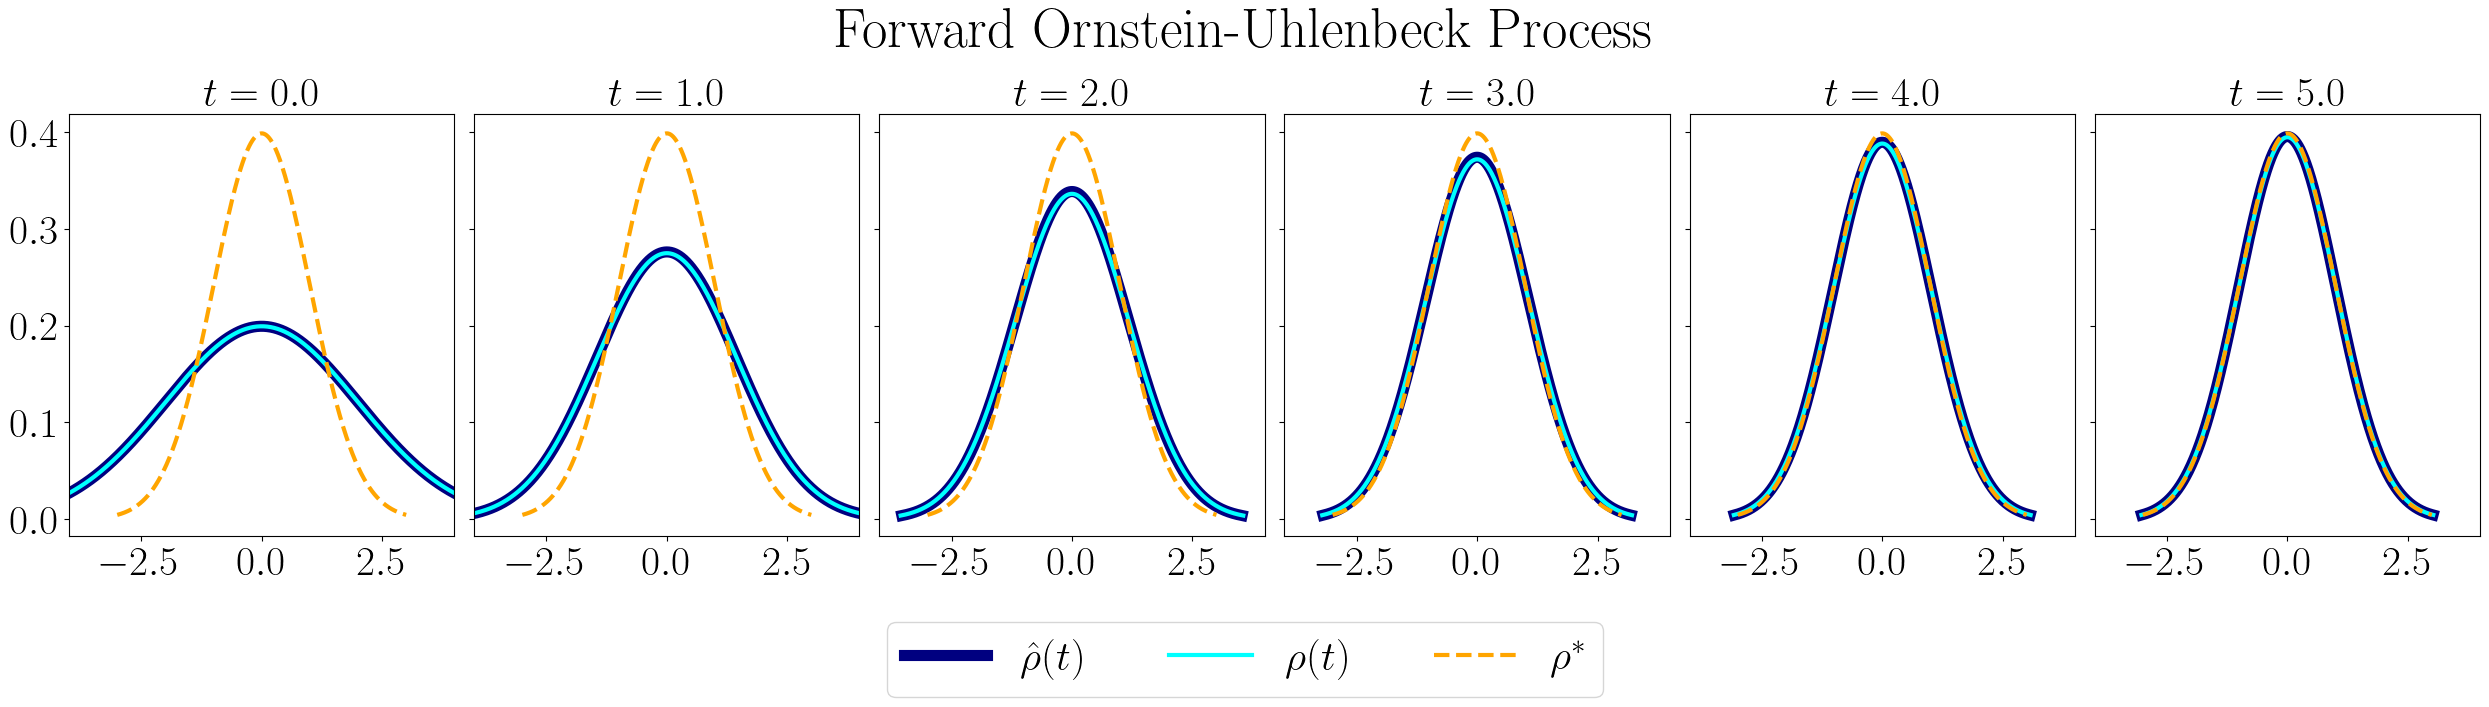

In [66]:
cmap = plt.get_cmap("gist_heat")
fig, axs = plt.subplots(1, 6, figsize=(25,6), sharey=True)
plt.suptitle("Forward Ornstein-Uhlenbeck Process", fontsize=40)

for i in range(len(plot_steps)):
    step = plot_steps[i]
    time = step*step_size
    xlim = 4
    color = cmap(i/len(plot_steps))

    true_var = 1 - (1-sigma_squared)*np.exp(-step*step_size)

    SB_var = forward_SB_var(sigma_squared, step_size, k=step)
    print(f'Step: {step}, idx: {plot_steps[i]//10}, true var: {true_var}, SB_var: {SB_var}')


    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(SB_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\hat \rho(t)$', color='navy', linewidth=8)
    else:
        axs[i].plot(x, pdf_values, color='navy', linewidth=8)      

    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(true_var))

    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\rho(t)$', color='aqua', linewidth=3)
    else:
        axs[i].plot(x, pdf_values, color='aqua', linewidth=3)  

    x, pdf_values = draw_gaussian(mean=0, std_dev=1)
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$ \rho^*$', color='orange', linewidth=3, linestyle='--')
    else:
        axs[i].plot(x, pdf_values, color='orange', linewidth=3, linestyle='--')        
    axs[i].set_xlim(-xlim, xlim)
    axs[i].set_title(f'$t = {time}$')

plt.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(plot_steps)+2)
plt.show()



### Reverse OU

In [63]:
# starting distribution

mean, sigma, sigma_squared = 0, 2, 4
step_size = 0.1
total_time = 5

tau_squared = sigma_squared*np.exp(-total_time) + (1 - np.exp(-total_time))
# SB scheme hyperparameters

max_steps = int(total_time/step_size)
step_gap = int(1/step_size)
plot_steps = step_gap*np.arange((max_steps//step_gap)+1)

Step: 0, idx: 0, true var: 1.0202138409972563, SB_var: 1.0202138409972563
Step: 10, idx: 1, true var: 1.0549469166662024, SB_var: 1.0524294359567496
Step: 20, idx: 2, true var: 1.1493612051035917, SB_var: 1.135987489804685
Step: 30, idx: 3, true var: 1.406005849709838, SB_var: 1.352703522536801
Step: 40, idx: 4, true var: 2.1036383235143274, SB_var: 1.914689266286438
Step: 50, idx: 5, true var: 4.0, SB_var: 3.3715558551917026


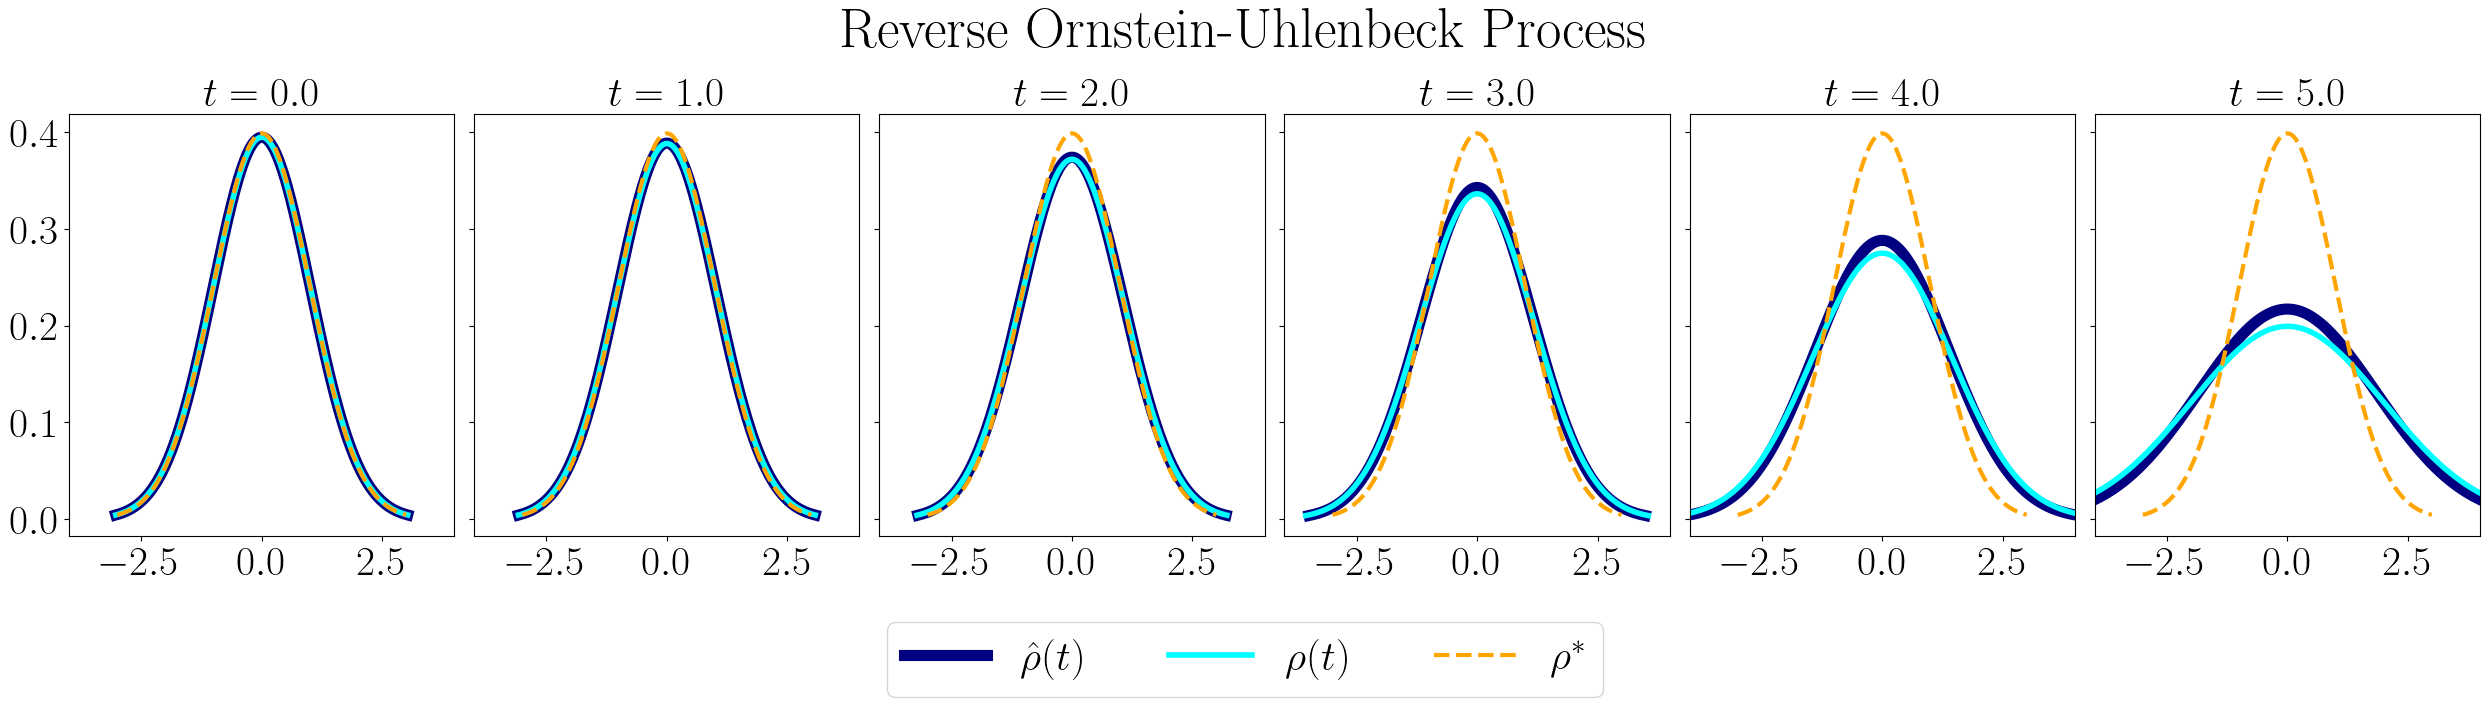

In [64]:
cmap = plt.get_cmap("gist_heat")
fig, axs = plt.subplots(1, 6, figsize=(25,6), sharey=True)

plt.suptitle("Reverse Ornstein-Uhlenbeck Process", fontsize=40)
for i in range(len(plot_steps)):
    step = plot_steps[i]
    time = step*step_size
    xlim = 4
    color = cmap(i/len(plot_steps))

    true_var = sigma_squared*np.exp(-(total_time - step*step_size)) + (1 - np.exp(-(total_time - step*step_size)))
    SB_var = reverse_SB_var(tau_squared, step_size, k=step)
    
    print(f'Step: {step}, idx: {plot_steps[i]//10}, true var: {true_var}, SB_var: {SB_var}')

    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(SB_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\hat \rho(t)$', color='navy', linewidth=8)
    else:
        axs[i].plot(x, pdf_values, color='navy', linewidth=8)   

    x, pdf_values = draw_gaussian(mean=0, std_dev=np.sqrt(true_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\rho(t)$', color='aqua', linewidth=4)
    else:
        axs[i].plot(x, pdf_values, color='aqua', linewidth=4)

    x, pdf_values = draw_gaussian(mean=0, std_dev=1)
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$ \rho^*$', color='orange', linewidth=3, linestyle='--')
    else:
        axs[i].plot(x, pdf_values, color='orange', linewidth=3, linestyle='--')  

    axs[i].set_xlim(-xlim, xlim)
    axs[i].set_title(f'$t = {time}$')

plt.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(plot_steps)+2)
plt.show()



### Example 1: Starting with Gaussian Mixture

### Forward

In [49]:
# starting distribution
mean, sigma, sigma_squared = 0, 0.5, 0.25
mu1, mu2 = -2, 2

# SB scheme hyperparameters
step_size = 0.01
total_time = 5
max_steps = int(total_time/step_size)
step_gap = int(1/step_size)
plot_steps = step_gap*np.arange((max_steps//step_gap)+1)

Step: 0, idx: 0, true var: 0.25, SB_var: 0.25
Step: 100, idx: 10, true var: 0.7240904191214181, SB_var: 0.7254702470461424
Step: 200, idx: 20, true var: 0.8984985375725405, SB_var: 0.8995131657586046
Step: 300, idx: 30, true var: 0.9626596987241021, SB_var: 0.9632185664137163
Step: 400, idx: 40, true var: 0.9862632708334493, SB_var: 0.9865368056432937
Step: 500, idx: 50, true var: 0.9949465397506859, SB_var: 0.9950720354435877


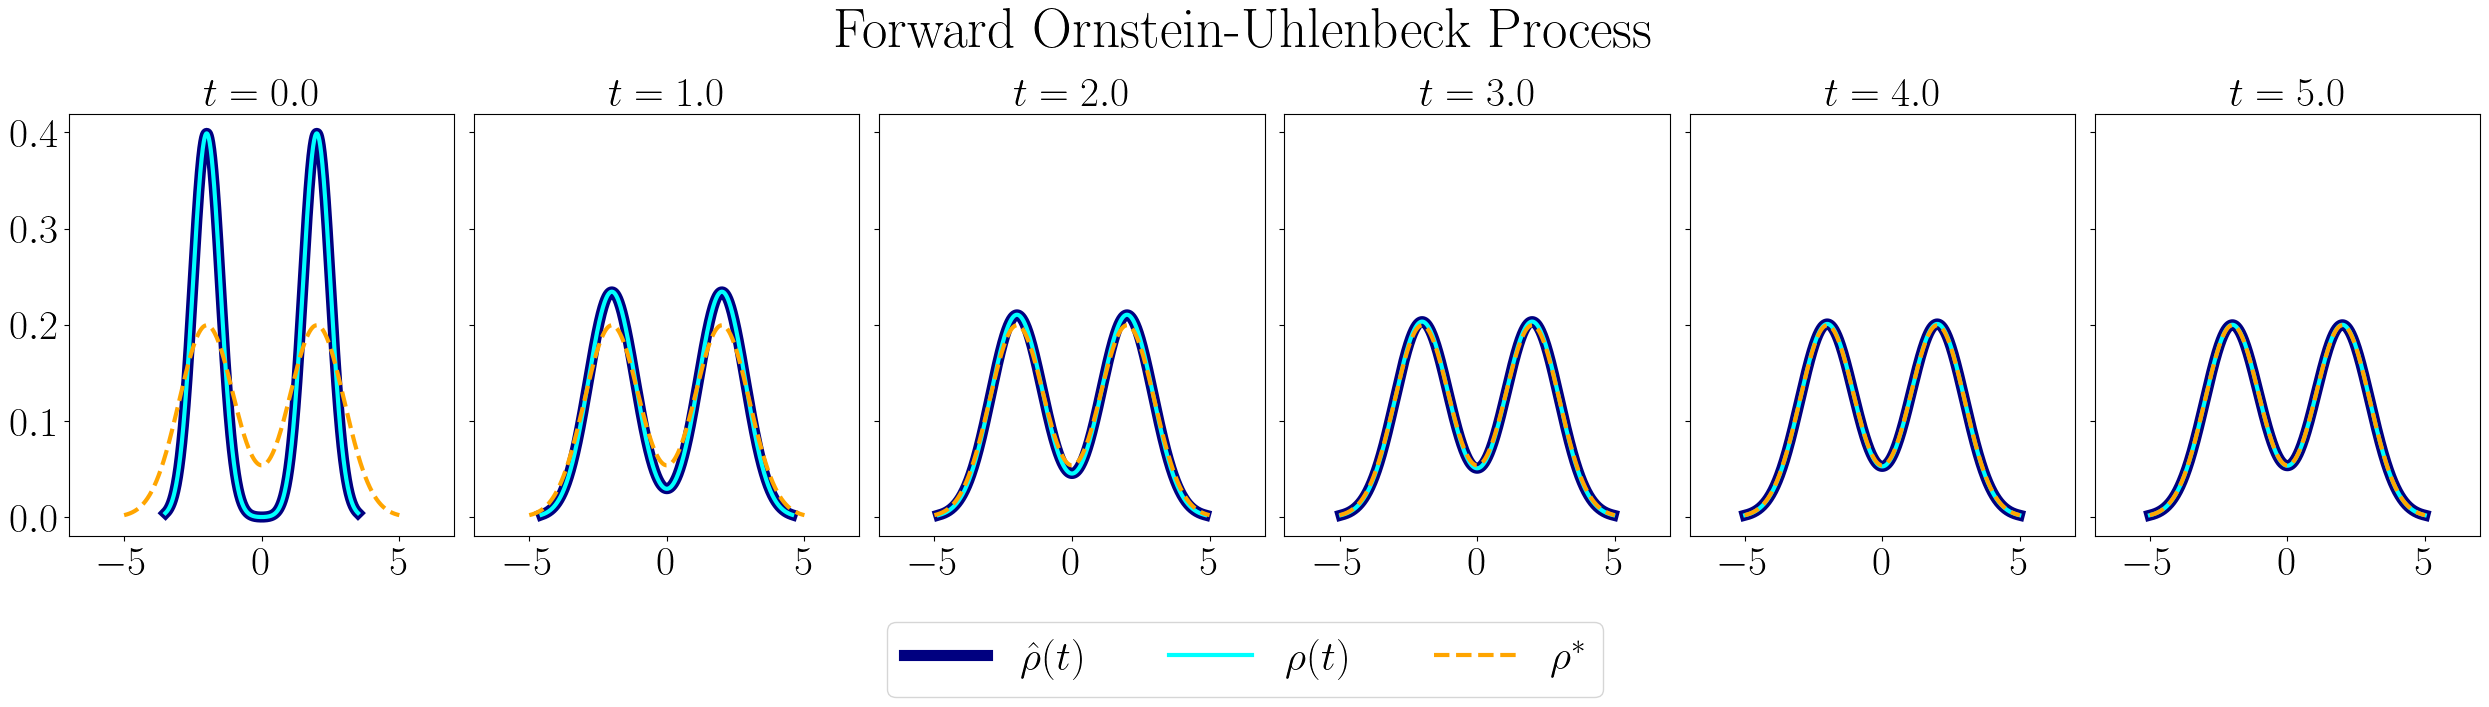

In [55]:
fig, axs = plt.subplots(1, 6, figsize=(25,6), sharey=True)
plt.suptitle("Forward Ornstein-Uhlenbeck Process", fontsize=40)

for i in range(len(plot_steps)):
    step = plot_steps[i]
    time = step*step_size
    xlim = 7
    color = cmap(i/len(plot_steps))

    true_var = 1 - (1-sigma_squared)*np.exp(-step*step_size)

    SB_var = forward_SB_var(sigma_squared, step_size, k=step)
    print(f'Step: {step}, idx: {plot_steps[i]//10}, true var: {true_var}, SB_var: {SB_var}')


    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=np.sqrt(SB_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\hat \rho(t)$', color='navy', linewidth=8)
    else:
        axs[i].plot(x, pdf_values, color='navy', linewidth=8)      

    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=np.sqrt(true_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\rho(t)$', color='aqua', linewidth=3)
    else:
        axs[i].plot(x, pdf_values, color='aqua', linewidth=3)  

    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=1)
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$ \rho^*$', color='orange', linewidth=3, linestyle='--')
    else:
        axs[i].plot(x, pdf_values, color='orange', linewidth=3, linestyle='--')        
    axs[i].set_xlim(-xlim, xlim)
    axs[i].set_title(f'$t = {time}$')

plt.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(plot_steps)+2)
plt.show()



### Reverse


In [56]:
# starting distribution

mean, sigma, sigma_squared = 0, 0.5, 0.25
step_size = 0.01
total_time = 5

tau_squared = sigma_squared*np.exp(-total_time) + (1 - np.exp(-total_time))
# SB scheme hyperparameters

max_steps = int(total_time/step_size)
step_gap = int(1/step_size)
plot_steps = step_gap*np.arange((max_steps//step_gap)+1)

Step: 0, idx: 0, true var: 0.9949465397506859, SB_var: 0.9949465397506859
Step: 100, idx: 10, true var: 0.9862632708334493, SB_var: 0.9863319192394612
Step: 200, idx: 20, true var: 0.9626596987241021, SB_var: 0.9630347603516204
Step: 300, idx: 30, true var: 0.8984985375725405, SB_var: 0.9000493766276956
Step: 400, idx: 40, true var: 0.7240904191214182, SB_var: 0.7299322464658922
Step: 500, idx: 50, true var: 0.25, SB_var: 0.2730527011360486


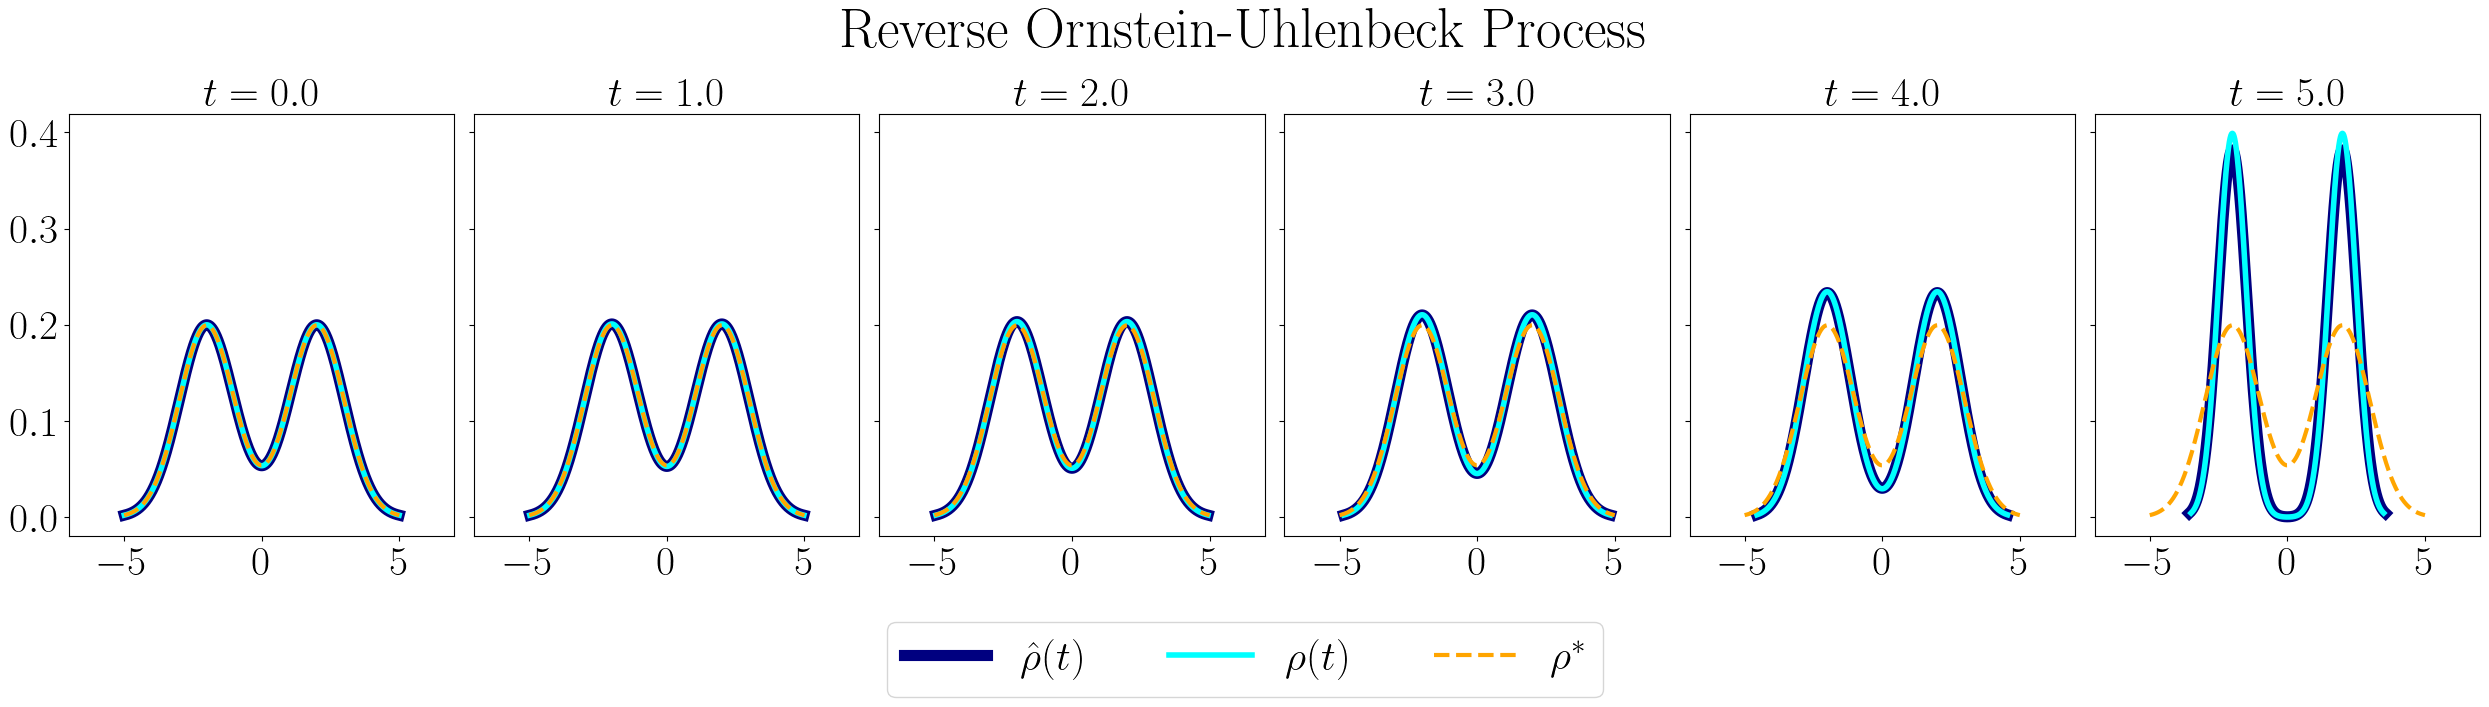

In [58]:
fig, axs = plt.subplots(1, 6, figsize=(25,6), sharey=True)

plt.suptitle("Reverse Ornstein-Uhlenbeck Process", fontsize=40)
for i in range(len(plot_steps)):
    step = plot_steps[i]
    time = step*step_size
    xlim = 7
    color = cmap(i/len(plot_steps))

    true_var = sigma_squared*np.exp(-(total_time - step*step_size)) + (1 - np.exp(-(total_time - step*step_size)))
    SB_var = reverse_SB_var(tau_squared, step_size, k=step)
    
    print(f'Step: {step}, idx: {plot_steps[i]//10}, true var: {true_var}, SB_var: {SB_var}')

    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=np.sqrt(SB_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\hat \rho(t)$', color='navy', linewidth=8)
    else:
        axs[i].plot(x, pdf_values, color='navy', linewidth=8)   

    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=np.sqrt(true_var))
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$\rho(t)$', color='aqua', linewidth=4)
    else:
        axs[i].plot(x, pdf_values, color='aqua', linewidth=4)

    x, pdf_values = draw_gaussian_mix(mu1=mu1, mu2=mu2, std_dev=1)
    if i == len(plot_steps)-1:
        axs[i].plot(x, pdf_values, label=r'$ \rho^*$', color='orange', linewidth=3, linestyle='--')
    else:
        axs[i].plot(x, pdf_values, color='orange', linewidth=3, linestyle='--')  

    axs[i].set_xlim(-xlim, xlim)
    axs[i].set_title(f'$t = {time}$')

plt.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(plot_steps)+2)
plt.show()

